In [1]:
# ══ CELL 1: Install all packages ══════════════════════════════════════════════
!pip install -q \
    ultralytics \
    easyocr \
    kaggle \
    opencv-python-headless \
    scikit-learn \
    onnxruntime \
    fast-alpr \
    super-image
print('✓ All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.9/95.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 37.6 MB/s eta 0:00:00
✓ All packages installed


In [2]:
# ══ CELL 2: Kaggle credentials ════════════════════════════════════════════════
import os, json

KAGGLE_USERNAME = 'andrewmvd'
KAGGLE_KEY      = 'KGAT_1886d4c81ccd3d2cbeb1a80efabc401d'

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✓ Kaggle credentials set')

✓ Kaggle credentials set


In [3]:
# ══ CELL 3: Download + prepare helmet dataset ═════════════════════════════════
import os, glob, shutil, yaml, cv2, zipfile, xml.etree.ElementTree as ET
from pathlib import Path
from sklearn.model_selection import train_test_split

# Download
if not os.path.exists('/content/helmet_data/images'):
    if os.path.exists('/content/helmet-detection.zip'):
        with zipfile.ZipFile('/content/helmet-detection.zip', 'r') as z:
            z.extractall('/content/helmet_data')
    else:
        !kaggle datasets download -d andrewmvd/helmet-detection -p /content/helmet_data --unzip -q

ROOT    = Path('/content/helmet_data')
IMG_DIR = ROOT / 'images'
ANN_DIR = ROOT / 'annotations'
OUT     = Path('/content/helmet_yolo')

CLASS_NAMES = ['With_Helmet', 'Without_Helmet']
class2id    = {c: i for i, c in enumerate(CLASS_NAMES)}

for split in ['train', 'val']:
    (OUT/split/'images').mkdir(parents=True, exist_ok=True)
    (OUT/split/'labels').mkdir(parents=True, exist_ok=True)

def voc_to_yolo(xml_path, iw, ih):
    lines = []
    for obj in ET.parse(xml_path).getroot().findall('object'):
        name = obj.find('name').text.strip()
        if name.lower() in ['with helmet','with_helmet','helmet']:
            name = 'With_Helmet'
        elif name.lower() in ['without helmet','without_helmet','no helmet','head']:
            name = 'Without_Helmet'
        if name not in class2id: continue
        bb = obj.find('bndbox')
        xmin,ymin,xmax,ymax = (float(bb.find(t).text) for t in ['xmin','ymin','xmax','ymax'])
        lines.append(f'{class2id[name]} {((xmin+xmax)/2)/iw:.6f} {((ymin+ymax)/2)/ih:.6f} {(xmax-xmin)/iw:.6f} {(ymax-ymin)/ih:.6f}')
    return lines

all_imgs = sorted(glob.glob(str(IMG_DIR/'*.png')) + glob.glob(str(IMG_DIR/'*.jpg')))
paired   = [p for p in all_imgs if (ANN_DIR/(Path(p).stem+'.xml')).exists()]
print(f'Found {len(paired)} annotated images')

tr, va = train_test_split(paired, test_size=0.15, random_state=42)

for split, lst in [('train',tr),('val',va)]:
    ok = 0
    for p in lst:
        stem = Path(p).stem
        img  = cv2.imread(p)
        if img is None: continue
        h, w = img.shape[:2]
        lines = voc_to_yolo(str(ANN_DIR/(stem+'.xml')), w, h)
        if not lines: continue
        shutil.copy(p, OUT/split/'images'/Path(p).name)
        with open(OUT/split/'labels'/(stem+'.txt'),'w') as f: f.write('\n'.join(lines))
        ok += 1
    print(f'  {split}: {ok} images')

HELMET_YAML = '/content/helmet.yaml'
with open(HELMET_YAML,'w') as f:
    yaml.dump({'train':str(OUT/'train'/'images'),'val':str(OUT/'val'/'images'),
               'nc':len(CLASS_NAMES),'names':CLASS_NAMES}, f)
print(f'✓ Helmet dataset ready')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/helmet-detection
License(s): CC0-1.0
Found 764 annotated images
  train: 646 images
  val: 115 images
✓ Helmet dataset ready


In [4]:
# ══ CELL 4: Train helmet detector ════════════════════════════════════════════
import torch
from ultralytics import YOLO

print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

res = YOLO('yolov8m.pt').train(
    data=HELMET_YAML, epochs=30, imgsz=640, batch=16,
    device=0 if torch.cuda.is_available() else 'cpu',
    name='helmet_v1', patience=10,
    hsv_v=0.4, mosaic=1.0, fliplr=0.5, degrees=10, scale=0.5,
)
HELMET_MODEL = str(res.save_dir) + '/weights/best.pt'
print(f'✓ Helmet model: {HELMET_MODEL}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: Tesla T4
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/helmet.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

In [12]:
# ══ CELL 5: Download pretrained plate model from HuggingFace ═════════════════
from huggingface_hub import hf_hub_download
import os

PLATE_MODEL = '/content/plate_best.pt'

if not os.path.exists(PLATE_MODEL):
    print('Downloading pretrained plate detection model...')
    try:
        # Primary: morsetechlab YOLOv11x — trained on large global plate dataset
        # YOLOv11 is fully compatible with ultralytics — loads same as YOLOv8
        path = hf_hub_download(
            repo_id='morsetechlab/yolov11-license-plate-detection',
            filename='yolov11x-license-plate.pt'
        )
        import shutil
        shutil.copy(path, PLATE_MODEL)
        print(f'✓ Primary model downloaded')
    except Exception as e:
        print(f'Primary failed ({e}), trying fallback...')
        try:
            # Fallback: yasirfaizahmed — YOLOv8 trained on keremberke dataset
            path = hf_hub_download(
                repo_id='yasirfaizahmed/license-plate-object-detection',
                filename='best.pt'
            )
            shutil.copy(path, PLATE_MODEL)
            print(f'✓ Fallback model downloaded')
        except Exception as e2:
            print(f'Both failed: {e2}')
            PLATE_MODEL = None
else:
    print('✓ Already downloaded')

print(f'PLATE_MODEL = {PLATE_MODEL}')

Primary failed (404 Client Error. (Request ID: Root=1-69bb926c-7be54d1d17c2556360fd23d4;4ef91c38-6c53-4888-a387-4c50d48b121e)

Entry Not Found for url: https://huggingface.co/morsetechlab/yolov11-license-plate-detection/resolve/main/yolov11x-license-plate.pt.), trying fallback...


best.pt:   0%|          | 0.00/6.24M [00:00<?, ?B/s]

✓ Fallback model downloaded
PLATE_MODEL = /content/plate_best.pt


In [13]:
# ══ CELL 6: Verify plate model ════════════════════════════════════════════════
import torch, torch.serialization
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

# Fix PyTorch 2.6 weights_only issue
torch.serialization.add_safe_globals([DetectionModel])

if PLATE_MODEL:
    test = YOLO(PLATE_MODEL)
    print(f'✓ Plate model loaded | classes: {test.names}')
    del test
else:
    print('⚠️ No plate model — will rely on ALPR only in Cell 7')

✓ Plate model loaded | classes: {0: "['plate']"}


In [24]:
# Install tesseract — run this once in a separate cell
!apt-get install -y tesseract-ocr -q
!pip install pytesseract -q

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [32]:
# ══ CELL 7: Load all models + define all helpers ══════════════════════════════

# Install fast-plate-ocr if not already done
import subprocess
subprocess.run(['pip', 'install', 'fast-plate-ocr', '-q'])

import cv2, io, re, torch
import numpy as np
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
from ultralytics import YOLO
from fast_alpr import ALPR
from fast_plate_ocr import LicensePlateRecognizer
import easyocr

# ── Load models ───────────────────────────────────────────────────────────────
helmet_model = YOLO(HELMET_MODEL)
plate_model  = YOLO(PLATE_MODEL)
person_model = YOLO('yolov8m.pt')

# ALPR with best global OCR model — 40+ countries including India
alpr = ALPR(
    detector_model='yolo-v9-t-384-license-plate-end2end',
    ocr_model='cct-s-v2-global-model',   # upgraded from mobile-vit
    detector_conf_thresh=0.10,            # lower — catches more plates
)

# Dedicated plate OCR — same model used by fast-alpr internally
plate_ocr = LicensePlateRecognizer('cct-s-v2-global-model')

ocr_reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

print(f'✓ Helmet model  | {helmet_model.names}')
print(f'✓ Plate model   | {plate_model.names}')
print(f'✓ Person model  | COCO')
print(f'✓ ALPR          | yolo-v9 + cct-s-v2-global')
print(f'✓ PlateOCR      | cct-s-v2-global-model')
print(f'✓ EasyOCR       | ready')

C_OK    = (0, 200, 0)
C_BAD   = (0, 0, 220)
C_PLATE = (0, 255, 0)

def show(bgr, title='', max_w=900):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil = PILImage.fromarray(rgb)
    if pil.width > max_w:
        pil = pil.resize((max_w, int(pil.height * max_w / pil.width)))
    buf = io.BytesIO()
    pil.save(buf, format='JPEG', quality=93)
    if title: print(f'\n─── {title} ───')
    display(IPImage(data=buf.getvalue()))

def draw_circle(f, x1, y1, x2, y2, tag, color):
    cx = int((x1+x2)/2); cy = int((y1+y2)/2)
    r  = int(max(x2-x1, y2-y1)/2) + 8
    cv2.circle(f, (cx,cy), r, color, 2)
    (tw,th),_ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.putText(f, tag, (cx-tw//2, cy-r-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

def classify(label, idx):
    l = label.lower().replace(' ','_')
    if any(k in l for k in ['without','no_helmet','nohelmet']): return 'no_helmet'
    if any(k in l for k in ['with_helmet','withhelmet','helmet']): return 'helmet'
    return 'no_helmet' if idx == 0 else 'helmet'

def iou(a, b):
    ax1,ay1,ax2,ay2 = a; bx1,by1,bx2,by2 = b
    ix1=max(ax1,bx1); iy1=max(ay1,by1); ix2=min(ax2,bx2); iy2=min(ay2,by2)
    inter = max(0,ix2-ix1)*max(0,iy2-iy1)
    if inter==0: return 0.0
    return inter/((ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter)

def super_resolve(crop):
    try:
        from super_image import EdsrModel, ImageLoader
        if not hasattr(super_resolve, '_model'):
            super_resolve._model = EdsrModel.from_pretrained('eugenesiow/edsr-base', scale=4)
            super_resolve._model.eval()
        pil = PILImage.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        inp = ImageLoader.load_image(pil)
        with torch.no_grad():
            out = super_resolve._model(inp)
        return cv2.cvtColor(np.array(ImageLoader.save_image(out)), cv2.COLOR_RGB2BGR)
    except Exception:
        h, w = crop.shape[:2]
        return cv2.resize(crop, (w*4, h*4), interpolation=cv2.INTER_CUBIC)

def read_plate_text(crop):
    """
    Three-engine OCR cascade on a plate crop:
    1. fast-plate-ocr (purpose-built, global model)
    2. EasyOCR
    3. Tesseract fallback
    Returns best result by length.
    """
    import pytesseract

    h, w = crop.shape[:2]
    up   = super_resolve(crop) if w < 150 else cv2.resize(crop, (w*3,h*3), interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(up, cv2.COLOR_BGR2GRAY)
    gray = cv2.fastNlMeansDenoising(gray, h=10)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4,4))
    gray  = clahe.apply(gray)
    gray  = cv2.filter2D(gray, -1, np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]))
    _, th_otsu = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    _, th_inv  = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    th_adapt   = cv2.adaptiveThreshold(gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY,15,4)

    candidates = []

    # Engine 1: fast-plate-ocr
    try:
        results = plate_ocr.run(crop)
        if results:
            text  = results[0].upper().strip()
            clean = re.sub(r'[^A-Z0-9]','',text)
            if len(clean)>=4 and re.search(r'[A-Z]',clean) and re.search(r'[0-9]',clean):
                candidates.append((len(clean), text))
    except Exception:
        pass

    # Engine 2: EasyOCR
    for img in [th_otsu, th_inv, th_adapt]:
        hits = ocr_reader.readtext(img, detail=1, paragraph=False,
                                    allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
                                    text_threshold=0.2, low_text=0.1,
                                    width_ths=2.0, ycenter_ths=2.0)
        hits = sorted(hits, key=lambda x: (sum(p[1] for p in x[0])/4,
                                            sum(p[0] for p in x[0])/4))
        text  = ' '.join(t.strip().upper() for _,t,c in hits if len(t.strip())>=1)
        text  = re.sub(r'\s+',' ',text).strip()
        clean = re.sub(r'[^A-Z0-9]','',text)
        if len(clean)>=4 and re.search(r'[A-Z]',clean) and re.search(r'[0-9]',clean):
            candidates.append((len(clean), text))

    # Engine 3: Tesseract
    for psm in [7, 6, 8]:
        cfg = f'--oem 3 --psm {psm} -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        for img in [th_otsu, th_inv]:
            try:
                text  = pytesseract.image_to_string(img, config=cfg).strip().upper()
                text  = re.sub(r'[^A-Z0-9 ]',' ',text).strip()
                text  = re.sub(r'\s+',' ',text)
                clean = re.sub(r'[^A-Z0-9]','',text)
                if len(clean)>=4 and re.search(r'[A-Z]',clean) and re.search(r'[0-9]',clean):
                    candidates.append((len(clean), text))
            except Exception:
                pass

    if not candidates: return None
    return sorted(candidates, reverse=True)[0][1]


def find_plate(img, result_frame):
    H, W  = img.shape[:2]
    crops = []

    # Source 1: ALPR detector
    for p in alpr.predict(img):
        b = p.detection.bounding_box
        x1,y1,x2,y2 = int(b.x1),int(b.y1),int(b.x2),int(b.y2)
        pad = 8
        px1,py1 = max(0,x1-pad),max(0,y1-pad)
        px2,py2 = min(W,x2+pad),min(H,y2+pad)

        # Use ALL confident chars — no aspect filter
        # ALPR already validated it's a plate during detection
        alpr_text  = ''.join(c for c,s in zip(p.ocr.text,p.ocr.confidence) if s>0.35).upper()
        alpr_clean = re.sub(r'[^A-Z0-9]','',alpr_text)

        # If ALPR text is already good — return immediately
        if len(alpr_clean)>=4 and re.search(r'[A-Z]',alpr_clean) and re.search(r'[0-9]',alpr_clean):
            cv2.ellipse(result_frame,
                ((px1+px2)//2,(py1+py2)//2),
                ((px2-px1)//2+10,(py2-py1)//2+10),
                0,0,360, C_PLATE, 3)
            return alpr_text

        # ALPR found plate but text unclear — add to OCR queue
        crops.append(((x2-x1)*(y2-y1), img[py1:py2,px1:px2],
                       (px1,py1,px2,py2), None))

    # Source 2: YOLO plate detector
    for box in plate_model.predict(img, conf=0.10, verbose=False)[0].boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        pad = 8
        px1,py1 = max(0,x1-pad),max(0,y1-pad)
        px2,py2 = min(W,x2+pad),min(H,y2+pad)
        crops.append(((x2-x1)*(y2-y1), img[py1:py2,px1:px2],
                       (px1,py1,px2,py2), None))

    crops.sort(key=lambda x: x[0], reverse=True)

    for area, crop, (px1,py1,px2,py2), hint in crops:
        ocr_text = read_plate_text(crop)
        best_candidates = []
        for t in [hint, ocr_text]:
            if not t: continue
            clean = re.sub(r'[^A-Z0-9]','',t)
            if len(clean)>=4 and re.search(r'[A-Z]',clean) and re.search(r'[0-9]',clean):
                best_candidates.append((len(clean), t))
        if best_candidates:
            best = sorted(best_candidates, reverse=True)[0][1]
            cv2.ellipse(result_frame,
                ((px1+px2)//2,(py1+py2)//2),
                ((px2-px1)//2+10,(py2-py1)//2+10),
                0,0,360, C_PLATE, 3)
            return best

    # Fallback: Tesseract sparse scan on bottom half
    import pytesseract
    print('  No plate detected — running Tesseract full scan...')
    bot   = img[H//2:H, 0:W]
    up    = cv2.resize(bot, (W*2,H), interpolation=cv2.INTER_CUBIC)
    gray  = cv2.cvtColor(up, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    gray  = clahe.apply(gray)
    _,th  = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    cfg   = '--oem 3 --psm 11 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    data  = pytesseract.image_to_data(th, config=cfg, output_type=pytesseract.Output.DICT)
    words = [(data['text'][i].strip().upper(), int(data['conf'][i]),
              data['left'][i], data['top'][i])
             for i in range(len(data['text']))
             if data['text'][i].strip() and int(data['conf'][i])>30]
    if not words: return 'NOT DETECTED'
    words.sort(key=lambda x:(x[3],x[2]))
    lines, cur = [], [words[0]]
    for w in words[1:]:
        if abs(w[3]-cur[-1][3])<20: cur.append(w)
        else: lines.append(cur); cur=[w]
    lines.append(cur)
    best_text, best_score = '', 0
    for line in lines:
        line.sort(key=lambda x:x[2])
        text  = ' '.join(w[0] for w in line)
        clean = re.sub(r'[^A-Z0-9]','',text)
        if len(clean)>best_score and re.search(r'[A-Z]',clean) and re.search(r'[0-9]',clean):
            best_score=len(clean); best_text=text
    return best_text if best_score>=4 else 'NOT DETECTED'

print('\n✓ All helpers ready — proceed to Cell 8')

INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['AzureExecutionProvider', 'CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.pipeline.license_plate:Initialized LicensePlateDetector with model /root/.cache/open-image-models/yolo-v9-t-384-license-plate-end2end/yolo-v9-t-384-license-plates-end2end.onnx


✓ Helmet model  | {0: 'With_Helmet', 1: 'Without_Helmet'}
✓ Plate model   | {0: "['plate']"}
✓ Person model  | COCO
✓ ALPR          | yolo-v9 + cct-s-v2-global
✓ PlateOCR      | cct-s-v2-global-model
✓ EasyOCR       | ready

✓ All helpers ready — proceed to Cell 8


Upload a bike / traffic image (JPG or PNG):


Saving WhatsApp Image 2026-03-18 at 11.40.47.jpeg to WhatsApp Image 2026-03-18 at 11.40.47.jpeg
WhatsApp Image 2026-03-18 at 11.40.47.jpeg  |  292×370

─── Original ───


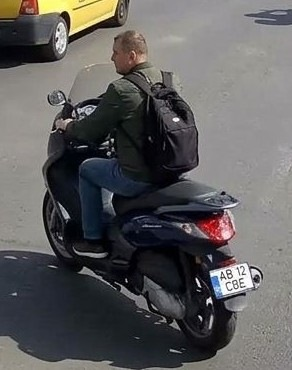


─── Final Result ───


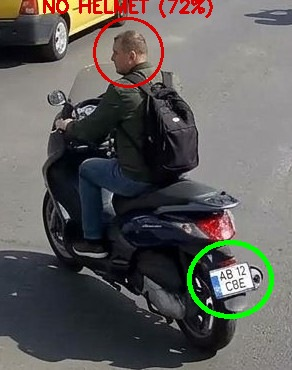


  ✅ Helmet    : 0
  🚨 No helmet : 1
  🔍 Plate     : AB12CBE


True

In [38]:
# ══ CELL 8: Upload image → detect helmets → detect plate → show result ════════
from google.colab import files

# ── Upload ────────────────────────────────────────────────────────────────────
print('Upload a bike / traffic image (JPG or PNG):')
up         = files.upload()
image_path = list(up.keys())[0]
frame      = cv2.imread(image_path)
H, W       = frame.shape[:2]
print(f'{image_path}  |  {W}×{H}')
show(frame, 'Original')

# ── Helmet detection ──────────────────────────────────────────────────────────
counts     = {'helmet':0, 'no_helmet':0}
violations = []
seen       = set()
result     = frame.copy()

# Stage 1: trained helmet model
helmet_boxes = []
for box in helmet_model.predict(frame, conf=0.45, iou=0.45, verbose=False)[0].boxes:
    conf         = float(box.conf[0])
    idx          = int(box.cls[0])
    status       = classify(helmet_model.names[idx], idx)
    x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
    key          = (int((x1+x2)/2)//20, int((y1+y2)/2)//20)
    if key in seen: continue
    seen.add(key)
    helmet_boxes.append({'status':status,'bbox':[x1,y1,x2,y2],'conf':conf})

# Stage 2: person detector for unmatched riders (catches rear-view)
person_boxes = []
for box in person_model.predict(frame, conf=0.25, iou=0.45,
                                  classes=[0], verbose=False)[0].boxes:
    x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
    person_boxes.append([x1,y1,x2,y2])

# Stage 3: draw helmet detections + match to persons
matched = set()
for hb in helmet_boxes:
    x1,y1,x2,y2 = hb['bbox']
    status = hb['status']
    counts[status] += 1
    tag = f'HELMET ({hb["conf"]:.0%})' if status=='helmet' else f'NO HELMET ({hb["conf"]:.0%})'
    draw_circle(result, x1,y1,x2,y2, tag, C_OK if status=='helmet' else C_BAD)
    if status=='no_helmet':
        violations.append({'bbox':[x1,y1,x2,y2]})
    # Match to persons
    for i, pb in enumerate(person_boxes):
        px1,py1,px2,py2 = pb
        upper = [px1,py1,px2,py1+int((py2-py1)*0.4)]
        if iou([x1,y1,x2,y2], upper) > 0.05:
            matched.add(i)

# Stage 4: unmatched persons = no helmet found → violation
for i, pb in enumerate(person_boxes):
    if i in matched: continue
    px1,py1,px2,py2 = pb
    if (px2-px1)*(py2-py1) < W*H*0.005: continue  # skip tiny distant people
    counts['no_helmet'] += 1
    draw_circle(result, px1,py1,px2,py2, 'NO HELMET', C_BAD)
    violations.append({'bbox':[px1,py1,px2,py2]})

# ── Plate detection ───────────────────────────────────────────────────────────
plate_text = find_plate(frame, result)

# ── Show result ───────────────────────────────────────────────────────────────
show(result, 'Final Result')
print(f'\n  ✅ Helmet    : {counts["helmet"]}')
print(f'  🚨 No helmet : {counts["no_helmet"]}')
print(f'  🔍 Plate     : {plate_text}')

# ── Download annotated image ──────────────────────────────────────────────────
out = 'result.jpg'
cv2.imwrite(out, result)

=== ALPR detections ===
  bbox=(207,260,253,299) | size=46x39 | aspect=1.18 | text=AB12CBE

─── ALPR crop (207,260) ───


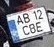


=== YOLO plate detections ===


In [31]:
# DEBUG: Show ALL detections from both sources
print('=== ALPR detections ===')
for p in alpr.predict(frame):
    b = p.detection.bounding_box
    x1,y1,x2,y2 = int(b.x1),int(b.y1),int(b.x2),int(b.y2)
    w,h = x2-x1, y2-y1
    aspect = w/h
    print(f'  bbox=({x1},{y1},{x2},{y2}) | size={w}x{h} | aspect={aspect:.2f} | text={p.ocr.text}')
    crop = frame[max(0,y1-4):y2+4, max(0,x1-4):x2+4]
    show(crop, f'ALPR crop ({x1},{y1})')

print('\n=== YOLO plate detections ===')
for box in plate_model.predict(frame, conf=0.10, verbose=False)[0].boxes:
    x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
    conf = float(box.conf[0])
    w,h  = x2-x1, y2-y1
    aspect = w/h
    print(f'  bbox=({x1},{y1},{x2},{y2}) | size={w}x{h} | aspect={aspect:.2f} | conf={conf:.2f}')
    crop = frame[max(0,y1-4):y2+4, max(0,x1-4):x2+4]
    show(crop, f'YOLO crop ({x1},{y1}) conf={conf:.2f}')

In [37]:
from google.colab import files

# Download helmet model
files.download('/content/runs/detect/helmet_v1/weights/best.pt')

# Download plate model
files.download('/content/runs/detect/plate_v1/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>